In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

df = pd.read_csv(
    r"C:\Users\Acer\Desktop\1st_Dataset_cleaned.csv"
)


X = df.drop("Daily_Liters_Used", axis=1)

y = df["Daily_Liters_Used"]


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("Mean Absolute Percentage Error:", mape, "%")


residuals = y_test - y_pred

print("Mean of Residuals:", residuals.mean())

joblib.dump(model, "water_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully")

Mean Absolute Error: 49.591645949773714
Mean Squared Error: 5033.023677956554
Root Mean Squared Error: 70.94380648059811
Mean Absolute Percentage Error: 8.662614837696088 %
Mean of Residuals: -5.537832382499479
Model and scaler saved successfully


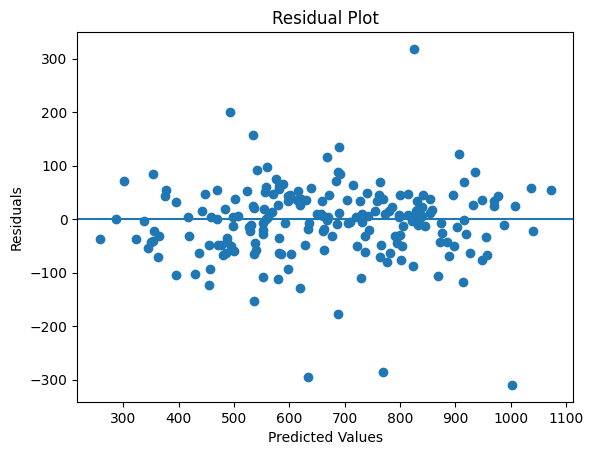

In [2]:
import matplotlib.pyplot as plt
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

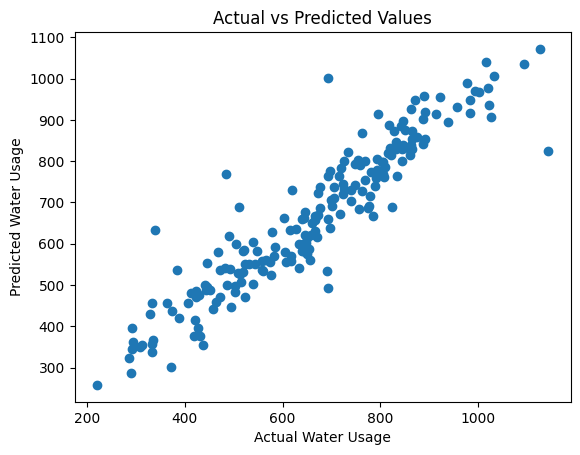

In [3]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Water Usage")
plt.ylabel("Predicted Water Usage")
plt.title("Actual vs Predicted Values")
plt.show()

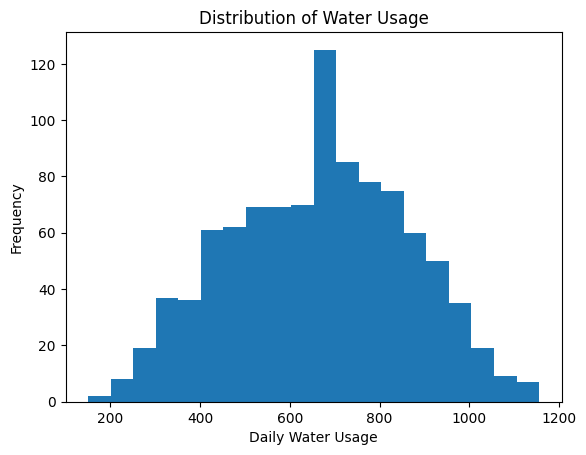

In [4]:
plt.hist(df["Daily_Liters_Used"], bins=20)
plt.xlabel("Daily Water Usage")
plt.ylabel("Frequency")
plt.title("Distribution of Water Usage")
plt.show()